# Object Detection Using YOLO v5 (Part-1)

### Welcome to the 9th Lab of 42028: Deep Learning and CNN!

In this part of the Lab/Tutorial session you will be exploring how to use the YOLO v5 object detector


So lets get started!


We will use the https://github.com/ultralytics/yolov5 repository for this tutorial

Reference: https://colab.research.google.com/github/ultralytics/yolov5/blob/master/tutorial.ipynb

# Step 1: Clone github repository

#### **Custom Dataset Setup (We will use Kangaroo dataset)**

In [1]:
# Change path to your file path location of the dataset as needed

## ENTER PATH TO DATASET ZIP FILE HERE ##
!unzip 'yoloV5_kangaroo.zip'

Archive:  yoloV5_kangaroo.zip
   creating: yolo_kangaroo/Kangaroo/
   creating: yolo_kangaroo/Kangaroo/test/
   creating: yolo_kangaroo/Kangaroo/test/images/
  inflating: yolo_kangaroo/Kangaroo/test/images/00001.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00002.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00003.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00004.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00005.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00006.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00007.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00009.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00010.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00011.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00012.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00013.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00014.jpg  
  inflating: yolo_kangaroo/Kangaroo/test/images/00016.jpg  
  

#### **Clone the Github Repo (Default location /root/)**

In [2]:
# By Default Cloned under root
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17889, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 17889 (delta 24), reused 3 (delta 0), pack-reused 17847 (from 4)
Receiving objects: 100% (17889/17889), 17.03 MiB | 22.42 MiB/s, done.
Resolving deltas: 100% (12179/12179), done.


Install the required libraries

In [6]:
!cd yolov5
#from yolov5 import utils
#display = utils.notebook_init()  # checks Pytorch and GPU used
!pip install -r requirements.txt

/bin/bash: line 1: cd: yolov5: No such file or directory


#### **Quick Reference on YAML**

#### [**What is YAML?**](https://circleci.com/blog/what-is-yaml-a-beginner-s-guide/)

YAML --> **Y**et **A**nother **M**arkup **L**anguage

YAML is a digestible data serialization language often used to create configuration files with any programming language.

Designed for human interaction, YAML is a strict superset of JSON, another data serialization language. But because it’s a strict superset, it can do everything that JSON can and more. One major difference is that newlines and indentation actually mean something in YAML, as opposed to JSON, which uses brackets and braces.

Reference and Source: https://circleci.com/blog/what-is-yaml-a-beginner-s-guide/ 

# Step 2: Setup Training Configuration

In [7]:
#@title Setup Training YAML File
number_of_classes = 1 #@param {type:"integer"}
with open('new_train_yaml', 'w+') as file:
    file.write(
        f"""
        # parameters
        nc: {number_of_classes}  # number of classes
        depth_multiple: 0.33  # model depth multiple
        width_multiple: 0.50  # layer channel multiple

        # anchors
        anchors:
          - [10,13, 16,30, 33,23]  # P3/8
          - [30,61, 62,45, 59,119]  # P4/16
          - [116,90, 156,198, 373,326]  # P5/32

        # YOLOv5 backbone
        backbone:
          # [from, number, module, args]
          [[-1, 1, Focus, [64, 3]],  # 0-P1/2
           [-1, 1, Conv, [128, 3, 2]],  # 1-P2/4
           [-1, 3, BottleneckCSP, [128]],
           [-1, 1, Conv, [256, 3, 2]],  # 3-P3/8
           [-1, 9, BottleneckCSP, [256]],
           [-1, 1, Conv, [512, 3, 2]],  # 5-P4/16
           [-1, 9, BottleneckCSP, [512]],
           [-1, 1, Conv, [1024, 3, 2]],  # 7-P5/32
           [-1, 1, SPP, [1024, [5, 9, 13]]],
           [-1, 3, BottleneckCSP, [1024, False]],  # 9
          ]

        # YOLOv5 head
        head:
          [[-1, 1, Conv, [512, 1, 1]],
           [-1, 1, nn.Upsample, [None, 2, 'nearest']],
           [[-1, 6], 1, Concat, [1]],  # cat backbone P4
           [-1, 3, BottleneckCSP, [512, False]],  # 13

           [-1, 1, Conv, [256, 1, 1]],
           [-1, 1, nn.Upsample, [None, 2, 'nearest']],
           [[-1, 4], 1, Concat, [1]],  # cat backbone P3
           [-1, 3, BottleneckCSP, [256, False]],  # 17 (P3/8-small)

           [-1, 1, Conv, [256, 3, 2]],
           [[-1, 14], 1, Concat, [1]],  # cat head P4
           [-1, 3, BottleneckCSP, [512, False]],  # 20 (P4/16-medium)

           [-1, 1, Conv, [512, 3, 2]],
           [[-1, 10], 1, Concat, [1]],  # cat head P5
           [-1, 3, BottleneckCSP, [1024, False]],  # 23 (P5/32-large)

           [[17, 20, 23], 1, Detect, [nc, anchors]],  # Detect(P3, P4, P5)
          ]
        """
    )

# Step 3: Setup Dataset paths

In [8]:
#@title Setup Dataset Configuration (Data.yaml)
train_data_dir = "../yolo_kangaroo/Kangaroo/train" #@param {type:"string"}
val_data_dir = "../yolo_kangaroo/Kangaroo/valid" #@param {type:"string"}
class_names = ['kangaroo'] #@param {type:"raw"}
with open('new_data_yaml', 'w+') as file:
    file.write(
        f"""
        train: {train_data_dir}
        val: {val_data_dir}

        nc: {number_of_classes}
        names: {class_names}
        """
    )

# Step 4: Start Training

**Configuation to try:**

*   **Image Size**: 416
*   **Batch Size**: 16
*   **Epochs**: 200
*   **Data Source details** : new_data_yaml (Created earlier)
*   **Training details** : new_train_yaml (Created earlier)

Example:
```shell
!python ../yolov5/train.py --img image_size --batch batch_size --epochs epochs --data /path/to/data/yml --cfg /path/to/train/yml
```

In [9]:
## ENTER CODE TO START TRAINING ##
!python ../yolov5/train.py --img 416 --batch 16 --epochs 200 --data ../yolov5/new_data_yaml --cfg ../yolov5/new_train_yaml


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/sagemaker-user/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2026-04-18 16:01:30.694549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776528090.723412     960 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776528090.735914     960 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
train: weights=yolov5s.pt, cfg=../yolov5/new_train_yaml, data=../yolov5/new_data_yaml, hyp=data/hyps/hyp.scratc

# Step 5: Test the trained model on sample images

### **Inference/Testing**
'detect.py' is used to run YOLOv5 testing/inference on different types of inputs such as: image, video, webcam input, directory glob, Youtube, RTSP/RTMP/HTTP Stream.

**Usage Syntax:**

```shell
python detect.py --source 0  # webcam
                          img.jpg  # image 
                          vid.mp4  # video
                          path/  # directory
                          path/*.jpg  # glob
                          'https://youtu.beZgi9g1ksQHc'  # YouTube
                          'rtsp://example.com/media.mp4'  # RTSP, RTMP, HTTP stream
                 --weights path/to/weights
                 --img 416
                 --conf 0.5
                 --save-txt
```
Example:
```shell
!python ../yolov5/detect.py --source '/path/to/img' --weights 'path/to/weights/best.pt' --img image_size --conf confidence_threshold --save-txt
```

In [10]:
!pwd
!cd ..

/home/sagemaker-user/42028/Week9/yolov5


In [11]:
## ENTER CODE TO START INFERENCE ON THE IMAGES
!python ../yolov5/detect.py --source '../yolo_kangaroo/Kangaroo/train/images/00001.jpg' --weights '../yolov5/runs/train/exp/weights/best.pt' --img 416 --conf 0.5 --save-txt

detect: weights=['../yolov5/runs/train/exp/weights/best.pt'], source=../yolo_kangaroo/Kangaroo/train/images/00001.jpg, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-472-g7ca403a3 Python-3.12.9 torch-2.6.0 CUDA:0 (Tesla T4, 14912MiB)

Fusing layers... 
new_train_yaml summary: 182 layers, 7246518 parameters, 0 gradients
image 1/1 /home/sagemaker-user/42028/Week9/yolo_kangaroo/Kangaroo/train/images/00001.jpg: 320x416 2 kangaroos, 31.2ms
Speed: 0.3ms pre-process, 31.2ms inference, 141.0ms NMS per image at shape (1, 3, 416, 416)
Results saved to runs/detect/exp
1 labels saved to runs/detect/exp/labels


# Step 6: Display result images

In [12]:
import cv2
from matplotlib import pyplot as plt
from PIL import Image

# This is needed to display the images.
%matplotlib inline

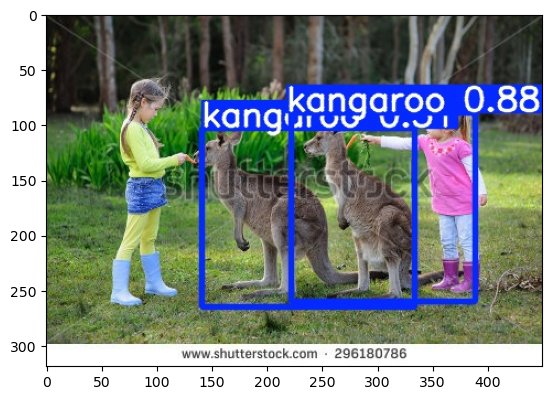

In [14]:
image = Image.open('../yolov5/runs/detect/exp/00001.jpg')
plt.imshow(image)

### Try on a Youtube video

In [5]:
# Interrupt runtime after 1 min if the video is too long
#!python ./yolov5/detect.py --source 'https://www.youtube.com/watch?v=wqctLW0Hb_0' --weights './yolov5/runs/train/exp/weights/best.pt'
!python ./yolov5/detect.py --source 'Kangaroo3.mov' --weights './yolov5/runs/train/exp/weights/best.pt' 

detect: weights=['./yolov5/runs/train/exp/weights/best.pt'], source=Kangaroo3.mov, data=yolov5/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-472-g7ca403a3 Python-3.12.9 torch-2.6.0 CUDA:0 (Tesla T4, 14912MiB)

Fusing layers... 
new_train_yaml summary: 182 layers, 7246518 parameters, 0 gradients
video 1/1 (1/348) /home/sagemaker-user/42028/Week9/Kangaroo3.mov: 384x640 2 kangaroos, 30.9ms
video 1/1 (2/348) /home/sagemaker-user/42028/Week9/Kangaroo3.mov: 384x640 2 kangaroos, 8.3ms
video 1/1 (3/348) /home/sagemaker-user/42028/Week9/Kangaroo3.mov: 384x640 2 kangaroos, 5.9ms
video 1/1 (4/348) /home/sage

### Download the Video file fron the folder to check the result video

# Step 7: Display performance analysis

Training results are automatically logged to Tensorboard and CSV as `results.csv`, which is plotted as `results.png` (below) after training completes. You can also plot any `results.csv` file manually:

In [6]:
#check the current directory
!pwd

/home/sagemaker-user/42028/Week9


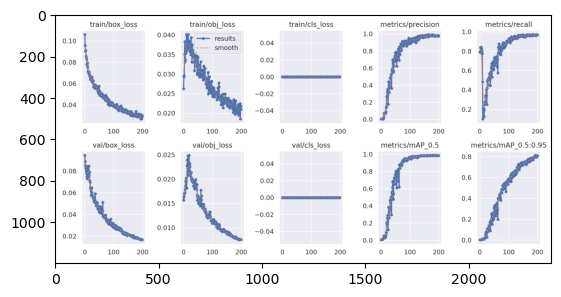

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
image = Image.open('./yolov5/runs/train/exp/results.png') # Change 'exp' to the last in the train directory
plt.imshow(image)